In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### import data 

In [19]:
data = yf.download('^NSEI', start = '2015-01-01', end = '2024-12-31',auto_adjust = True)
returns = np.log(data['Close']/data['Close'].shift(1)).dropna()*100


[*********************100%***********************]  1 of 1 completed


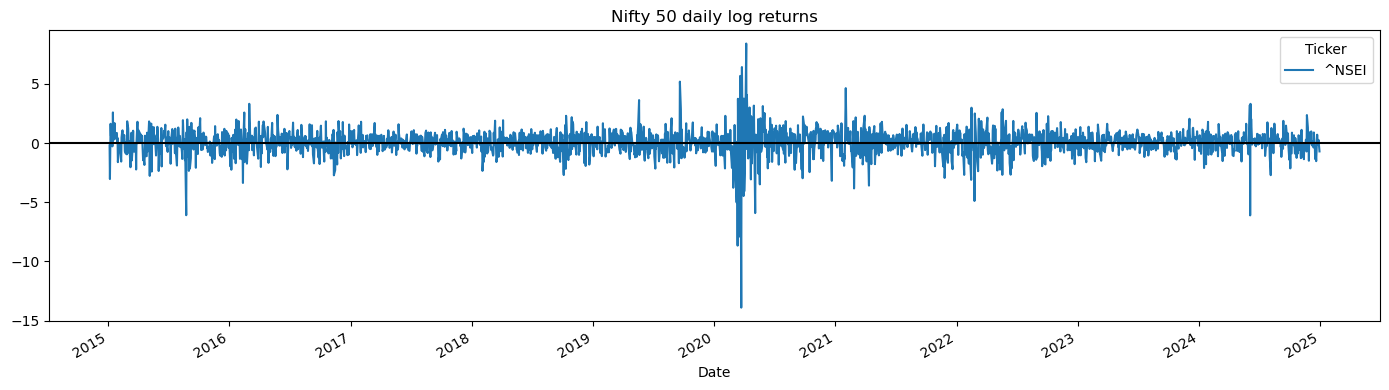

In [26]:
returns.plot(figsize = (14,4), title = 'Nifty 50 daily log returns')
plt.axhline(0,color = 'black')
plt.tight_layout()

### Engels' ARCH-LM test to check if GARCH model is to be used or not
#### p < 0.05 → proceed with GARCH

In [36]:
from statsmodels.stats.diagnostic import het_arch
# h0 : No arch effects
# h1: ARCH effects are present
lm_stat, lm_pval, f_stat, f_pval = het_arch(returns, nlags = 10)
#nlags:10 is to check if the squared log returns of the last 10 days predict today's variance
print(f'LM-statistic:{lm_stat:.2f}')
print(f'p-value:{lm_pval:.2f}')

LM-statistic:638.80
p-value:0.00


In [35]:
# p-value:0.00 , reject null hypothesis-> there are GARCH effects

In [42]:
from arch import arch_model

model = arch_model(returns, mean = 'Constant', vol = 'GARCH', p =1, q = 1, dist = 'normal')
result = model.fit(disp ='off')
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - GARCH Model Results                      
==============================================================================
Dep. Variable:                  ^NSEI   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3192.39
Distribution:                  Normal   AIC:                           6392.78
Method:            Maximum Likelihood   BIC:                           6416.01
                                        No. Observations:                 2457
Date:                Thu, Apr 30 2026   Df Residuals:                     2456
Time:                        15:33:09   Df Model:                            1
                                Mean Model                                
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0721  1.759e-02      4.101  4.107e-05 [3.766e-02,  0.107]
                              Volatility Model                              
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega          0.0298  1.042e-02      2.856  4.294e-03 [9.336e-03,5.019e-02]
alpha[1]       0.1100  2.629e-02      4.183  2.876e-05   [5.844e-02,  0.161]
beta[1]        0.8609  3.042e-02     28.303 3.151e-176     [  0.801,  0.921]
============================================================================

Covariance estimator: robust
"""

In [44]:
# mean daily log return: 7.21%
# alpha[1] measures Measures how much yesterday's surprise (shock) impacts today's volatility
# A value of 0.11 means ~11% of the previous period's squared shock feeds into current volatility, 
# beta[1] measures how much yesterday's volatility carries into today
# At 0.86, this is very high persistence — volatility decays slowly once elevated
# alpha + beta ~ 1; This is close to 1, meaning volatility is highly persistent — shocks take a long time to die out.

### Annualise conditional probability

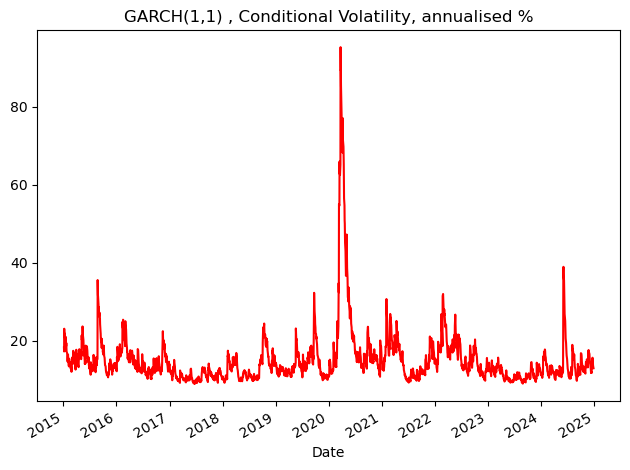

In [50]:
cond_vol = result.conditional_volatility * np.sqrt(252)
cond_vol.plot(color = 'red')
plt.title('GARCH(1,1) , Conditional Volatility, annualised %')
plt.tight_layout()

### Fit student-t and EGARCH and then comapre AIC

In [54]:
model_t = arch_model(returns, mean = 'Constant',vol = 'Garch', p =1 ,q =1,dist = 't')
result_t = model_t.fit(disp = 'off')

model_e = arch_model(returns, mean = 'Constant', vol = 'EGarch', p=1 ,o = 1, q = 1, dist = 't') # o = 1, adds gamma(asymmetry) term to the model(levergage effect)
result_e = model_e.fit(disp = 'off')

#AIC
print(f"GARCH(1,1):Normal:{result.aic:.2f}")
print(f"GARCH(1,1):Student-t:{result_t.aic:.2f}")
print(f"EGARCH(1,1):Student-t:{result_e.aic:.2f}")

GARCH(1,1):Normal:6392.78
GARCH(1,1):Student-t:6265.92
EGARCH(1,1):Student-t:6198.98


In [ ]:
# EGARCH(1,1) has the least AIC

### Residual Diagnostic
##### to check whether selected model has captured all the variance structure

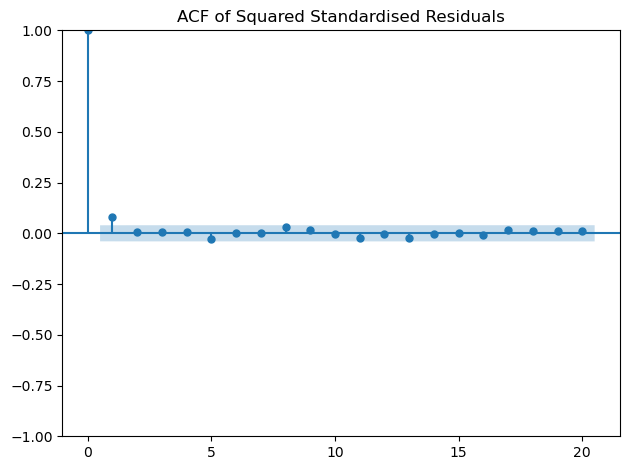

Residual ARCH-LM p-value: 0.0199
ARCH effects remain — try higher order


In [58]:
from scipy import stats

std_resid = result_e.std_resid

#to check if standardised residuals are correlated 
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(std_resid**2, lags=20, title="ACF of Squared Standardised Residuals")
plt.tight_layout()
plt.show()

# ARCH-LM test on residuals — should show no remaining ARCH effects
lm2, pval2, _, _ = het_arch(std_resid, nlags=10)
print(f"Residual ARCH-LM p-value: {pval2:.4f}")
print("Model well-specified" if pval2 > 0.05 else "ARCH effects remain — try higher order")

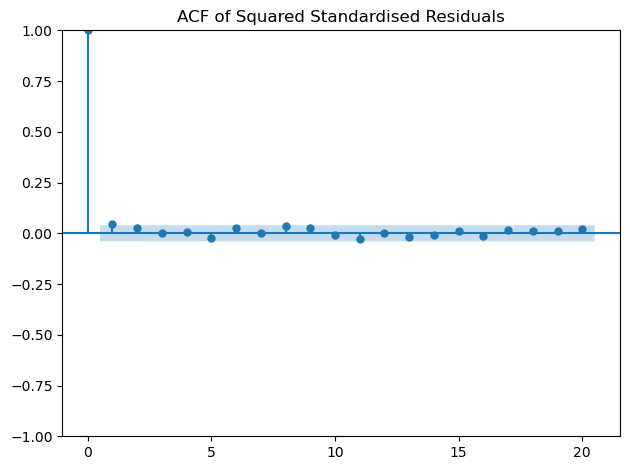

Residual ARCH-LM p-value: 0.1101
Model well-specified
Kurtosis of std residuals: 2.314


In [64]:
std_resid = result_t.std_resid

#to check if standardised residuals are correlated 
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(std_resid**2, lags=20, title="ACF of Squared Standardised Residuals")
plt.tight_layout()
plt.show()

# ARCH-LM test on residuals — should show no remaining ARCH effects
lm2, pval2, _, _ = het_arch(std_resid, nlags=10)
print(f"Residual ARCH-LM p-value: {pval2:.4f}")
print("Model well-specified" if pval2 > 0.05 else "ARCH effects remain — try higher order")

#Normality of standardised residuals (expect fat tails even after Student-t)
print(f"Kurtosis of std residuals: {stats.kurtosis(std_resid):.3f}")
# > 0 means leptokurtic (fat tails), which is normal for financial data

In [61]:
# choose garch student t since residual diagnostic clears

In [63]:
from statsmodels.stats.diagnostic import acorr_ljungbox

std_resid_e = result_e.std_resid
lb = acorr_ljungbox(std_resid_e**2, lags=[5, 10, 15, 20], return_df=True)
lb

,lb_stat,lb_pvalue
5,17.548265,0.003569
10,20.351155,0.026101
15,23.006004,0.084012
20,24.868499,0.206508


In [67]:
# Forecast next 10 trading days of variance
forecast = result_t.forecast(horizon=10)
forecast_vol = np.sqrt(forecast.variance.iloc[-1]) * np.sqrt(252)

print("10-day Annualised Volatility Forecast:")
print(forecast_vol.to_string())

10-day Annualised Volatility Forecast:
h.01    13.112691
h.02    13.173854
h.03    13.232772
h.04    13.289537
h.05    13.344237
h.06    13.396958
h.07    13.447778
h.08    13.496773
h.09    13.544017
h.10    13.589577
